# 第 3 课：频谱、DFT 与 FFT

这一课回答：波形里有哪些频率？计算机怎样把混合波拆开？DFT 和 FFT 是什么关系？

学习路线：单一纯音 → 混合纯音 → 频谱峰 → DFT 的匹配思想 → FFT 为什么存在 → 频率 bin → 真实语音帧。

你不需要先会复数。先理解‘用不同频率去匹配原信号’，再逐渐接触公式。

<!-- course-upgrade-v2 -->
## 学习导航

| 项目 | 内容 |
|---|---|
| 所属阶段 | 声音与声学特征 |
| 建议投入 | 2～4 小时，可分 2～3 次完成 |
| 前置要求 | 完成第 2 课；如果前测低于 2/3，先回看上一课小结 |
| 本课核心 | DFT、FFT、频率 bin |
| 完成标准 | 能口头解释核心概念；独立完成强化题；从空白重写核心函数 |

高效顺序：**先回答前测 → 预测代码结果 → 再运行 → 修改一个变量 → 关闭答案复现 → 次日回忆。**


<!-- course-upgrade-v2 -->
## 课前诊断（先不要运行代码）

1. 分别用一句话解释：DFT、FFT、频率 bin。
2. 画出这三个概念之间的输入—输出关系。
3. 写下你最不确定的一点，并给出一个暂时猜测。

自评：答对 0～1 题先复习前置课；答对 2 题可以正常学习；3 题都能讲清楚则直接挑战代码和迁移题。


<!-- course-bridge-v3 -->
## 知识接力：先取回旧知识，再进入本课

### 3 分钟闭卷回忆

在新 Markdown cell 中回答，**不要先翻前文**：正弦波的频率、周期、相位；波形叠加；采样率与可表示频率的关系。

- 三项都能用“含义 + 单位/shape + 一个数字例子”回答：进入本课。
- 能回答两项：学习本课，但把缺口记入 `LEARNING_LOG.md`。
- 只能回答零到一项：先回到 [音频基础 2、4、5](音频零基础课程索引.md)，做一次最小实验；不要靠继续看新术语掩盖断点。

### 本课接口契约

```text
输入：一帧波形 `[N]` 与采样率
  ↓ 本课要学会的变换、状态或判断
输出：复数 DFT/FFT 与带 Hz 坐标的频谱 bin
```

学完后必须能解释：输入的哪个单位/shape/状态若丢失，会让输出“仍能运行却语义错误”。


## 0. 准备

运行下面的单元格导入库。

In [1]:
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import ipywidgets as widgets

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

## 1. 波形只告诉你‘随时间怎么变’

一个纯音可以写成 $x(t)=A\sin(2\pi ft)$。横轴是时间，纵轴是振幅。频率越高，同一段时间内振荡次数越多。

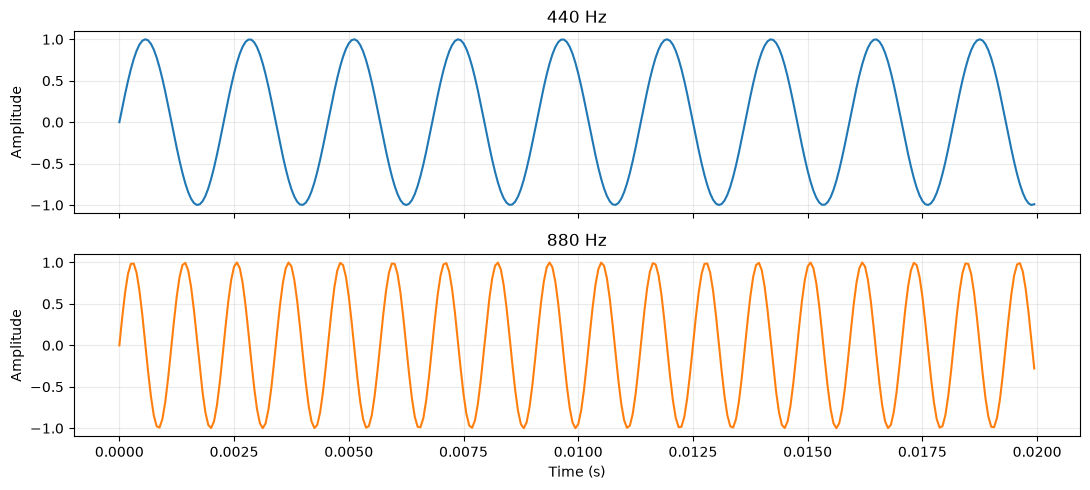

In [2]:
sr = 16_000
duration = 0.02
t = np.arange(round(sr*duration)) / sr
x440 = np.sin(2*np.pi*440*t)
x880 = np.sin(2*np.pi*880*t)
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, x440); axes[0].set_title('440 Hz')
axes[1].plot(t, x880, color='tab:orange'); axes[1].set_title('880 Hz')
for ax in axes: ax.set_ylabel('Amplitude'); ax.grid(alpha=0.25)
axes[1].set_xlabel('Time (s)'); plt.tight_layout(); plt.show()

### 热身题

1. 20 ms 内，880 Hz 的波形为什么比 440 Hz 更密？
2. 波形的高度主要对应振幅还是频率？
3. 如果两个频率混合在一起，仅看波形是否容易直接读出它们？

## 2. 混合波：两个频率可以相加

真实声音通常不是单个正弦波。下面把 440 Hz 与 1000 Hz 相加。时域波形变复杂，但频谱会把它们重新分开。

<USER_HOME>\AppData\Local\Temp\ipykernel_15392\628108317.py:9: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  axes[2].set_xlabel('Time (s)'); plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\628108317.py:9: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  axes[2].set_xlabel('Time (s)'); plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\628108317.py:9: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  axes[2].set_xlabel('Time (s)'); plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\628108317.py:9: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  axes[2].set_xlabel('Time (s)'); plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\628108317.py:9: UserWarning: Glyph 25391 (\N{CJK UNIFIED IDEOGRAPH-632F}) missing from font(s) 

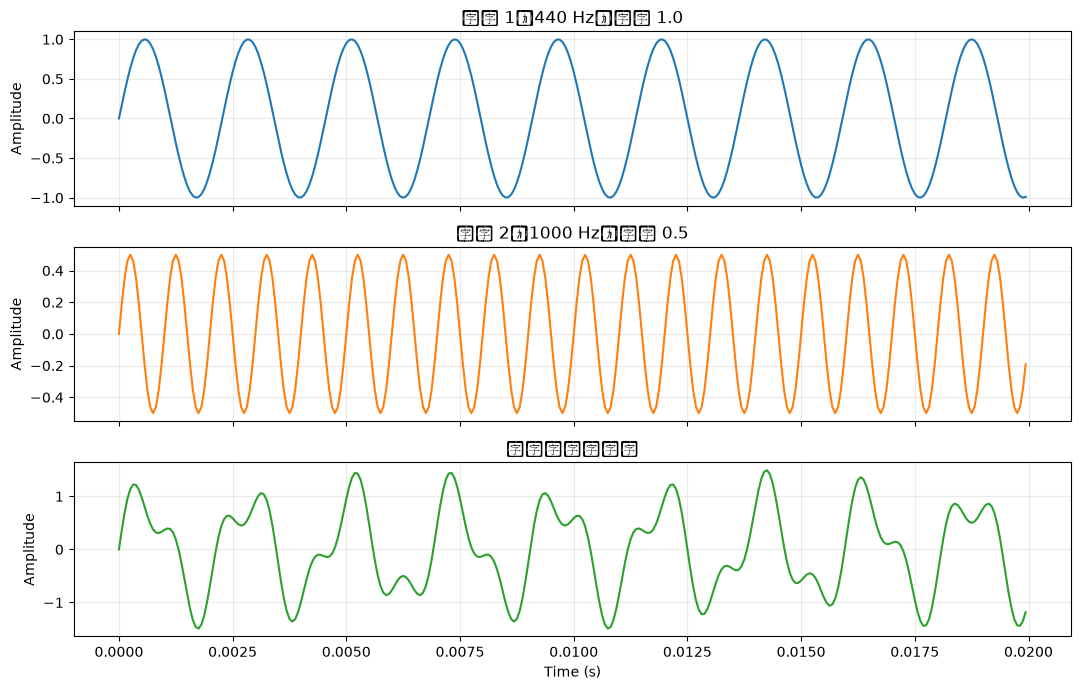

In [3]:
x1 = 1.0*np.sin(2*np.pi*440*t)
x2 = 0.5*np.sin(2*np.pi*1000*t)
mixture = x1 + x2
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(t, x1); axes[0].set_title('成分 1：440 Hz，振幅 1.0')
axes[1].plot(t, x2, color='tab:orange'); axes[1].set_title('成分 2：1000 Hz，振幅 0.5')
axes[2].plot(t, mixture, color='tab:green'); axes[2].set_title('相加后的混合波')
for ax in axes: ax.set_ylabel('Amplitude'); ax.grid(alpha=0.25)
axes[2].set_xlabel('Time (s)'); plt.tight_layout(); plt.show()

## 3. 频谱：横轴从时间变成频率

FFT 的输出是复数。现在先忽略复数细节，取绝对值得到 magnitude spectrum。频谱峰的位置表示频率，峰的高度表示该频率成分的相对强弱。

<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 38468 (\N{CJK UNIFIED IDEOGRAPH-9644}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

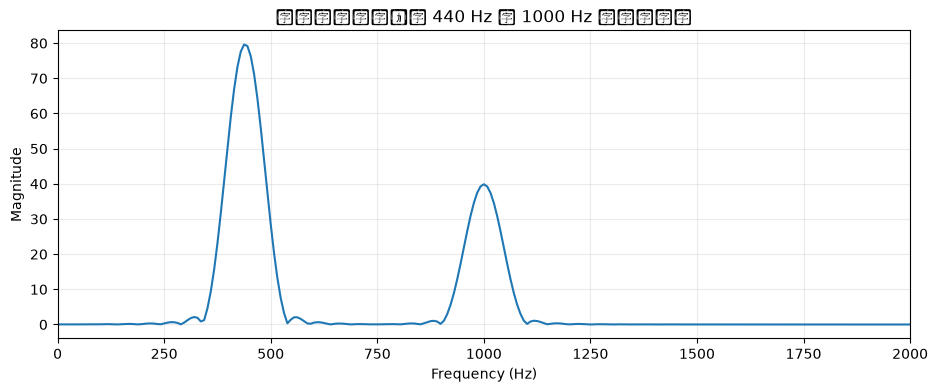

In [4]:
n_fft = 2048
spectrum = np.fft.rfft(mixture*np.hanning(len(mixture)), n=n_fft)
magnitude = np.abs(spectrum)
freqs = np.fft.rfftfreq(n_fft, d=1/sr)
plt.figure(figsize=(11, 4))
plt.plot(freqs, magnitude)
plt.xlim(0, 2000)
plt.xlabel('Frequency (Hz)'); plt.ylabel('Magnitude')
plt.title('混合波的频谱：在 440 Hz 和 1000 Hz 附近出现峰')
plt.grid(alpha=0.25); plt.show()

### 练习 1：看图题

1. 两个主要峰分别在哪里？
2. 为什么 1000 Hz 的峰比 440 Hz 的峰低？
3. 如果给混合波再加一个振幅 0.2 的 1500 Hz 正弦波，你预测频谱会怎样变化？

## 4. 交互实验：自己混合三个频率

拖动频率和振幅，左边看波形，右边看频谱。注意：波形可能变化得很复杂，但频谱峰仍然容易辨认。

In [5]:
def draw_mixture(f1=300, f2=700, f3=1200, a2=0.6, a3=0.3):
    sr_local = 8000
    tt = np.arange(round(0.05*sr_local))/sr_local
    xx = np.sin(2*np.pi*f1*tt) + a2*np.sin(2*np.pi*f2*tt) + a3*np.sin(2*np.pi*f3*tt)
    spec = np.abs(np.fft.rfft(xx*np.hanning(len(xx)), n=2048))
    ff = np.fft.rfftfreq(2048, 1/sr_local)
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
    axes[0].plot(tt, xx); axes[0].set_xlim(0, 0.02)
    axes[0].set(title='Waveform', xlabel='Time (s)', ylabel='Amplitude')
    axes[1].plot(ff, spec); axes[1].set_xlim(0, 2000)
    axes[1].set(title='Magnitude spectrum', xlabel='Frequency (Hz)', ylabel='Magnitude')
    for ax in axes: ax.grid(alpha=0.25)
    plt.tight_layout(); plt.show()

widgets.interact(
    draw_mixture,
    f1=widgets.IntSlider(value=300,min=100,max=1500,step=50,description='f1'),
    f2=widgets.IntSlider(value=700,min=100,max=1500,step=50,description='f2'),
    f3=widgets.IntSlider(value=1200,min=100,max=1500,step=50,description='f3'),
    a2=widgets.FloatSlider(value=0.6,min=0,max=1,step=0.1,description='a2'),
    a3=widgets.FloatSlider(value=0.3,min=0,max=1,step=0.1,description='a3')
)

interactive(children=(IntSlider(value=300, description='f1', max=1500, min=100, step=50), IntSlider(value=700,…

<function __main__.draw_mixture(f1=300, f2=700, f3=1200, a2=0.6, a3=0.3)>

### 交互题 A

1. 把三个频率设为 300、700、1200 Hz，数出三个峰。
2. 把 a3 调成 0，哪个峰消失？
3. 把 f1 和 f2 都设成 500 Hz，会看到两个峰还是一个峰？为什么？
4. 改变振幅时，峰的位置会移动吗？

## 5. DFT 的直觉：拿不同频率逐个匹配

可以把 DFT 想成一组检测器：100 Hz 检测器、200 Hz 检测器、300 Hz 检测器……每个检测器用对应的正弦/余弦波与原信号比较。越相似，匹配分数越大。

下面不用 FFT，直接计算指定候选频率和信号的匹配程度。

<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36880 (\N{CJK UNIFIED IDEOGRAPH-9010}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21305 (\N{CJK UNIFIED IDEOGRAPH-5339}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

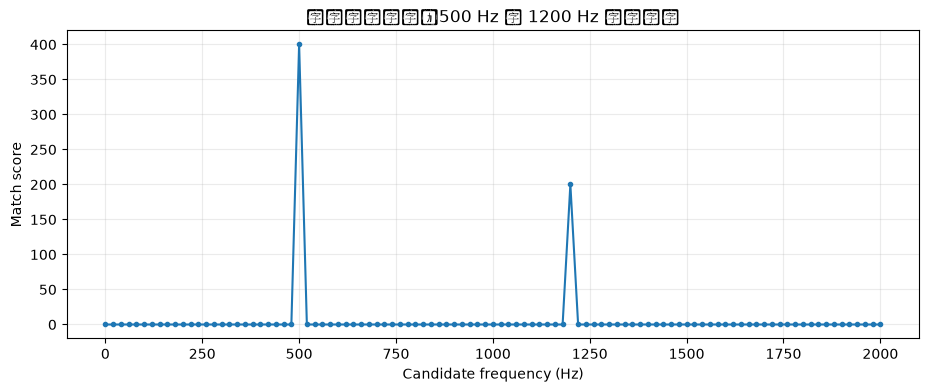

In [6]:
sr_small = 8000
tt = np.arange(round(0.1*sr_small))/sr_small
xx = np.sin(2*np.pi*500*tt) + 0.5*np.sin(2*np.pi*1200*tt)
candidates = np.arange(0, 2001, 20)
scores = []
for f in candidates:
    cosine_score = np.sum(xx*np.cos(2*np.pi*f*tt))
    sine_score = np.sum(xx*np.sin(2*np.pi*f*tt))
    scores.append(np.sqrt(cosine_score**2 + sine_score**2))
plt.figure(figsize=(11, 4))
plt.plot(candidates, scores, 'o-', markersize=3)
plt.xlabel('Candidate frequency (Hz)'); plt.ylabel('Match score')
plt.title('逐个频率匹配：500 Hz 与 1200 Hz 得分最高')
plt.grid(alpha=0.25); plt.show()

为什么同时需要正弦和余弦？因为同一频率可能有不同的起始相位。只和正弦比较，某些相位下会误判；正弦与余弦共同描述后，就能得到与相位无关的幅度。复数指数只是把这两个匹配过程紧凑地写在一起。

## 6. DFT 公式：先认识符号，不要求背诵

$$X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}$$

- $x[n]$：第 n 个时域采样点。
- $X[k]$：第 k 个频率 bin 的结果。
- 求和：让第 k 个频率检测器检查所有采样点。
- $e^{-j\theta}$：同时包含余弦和正弦。

DFT 是数学变换；FFT 是快速计算同一个 DFT 结果的算法。

In [7]:
def slow_dft(x):
    x = np.asarray(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    matrix = np.exp(-2j*np.pi*k*n/N)
    return matrix @ x

tiny = np.array([1.0, 0.0, -1.0, 0.0])
print('手写 DFT:', np.round(slow_dft(tiny), 6))
print('NumPy FFT:', np.round(np.fft.fft(tiny), 6))
print('结果相同:', np.allclose(slow_dft(tiny), np.fft.fft(tiny)))

手写 DFT: [0.+0.j 2.+0.j 0.-0.j 2.+0.j]
NumPy FFT: [0.+0.j 2.+0.j 0.+0.j 2.+0.j]
结果相同: True


### 练习 2

1. DFT 与 FFT 的输出是否是两种不同的频谱？
2. FFT 为什么存在？
3. 上面 `np.allclose` 为什么应当得到 True？

答案：不是，FFT 只是更快计算 DFT；直接 DFT 计算量大；两者数学结果相同。

## 7. FFT 为什么快？

直接 DFT 大约需要 $N^2$ 次操作，FFT 利用重复结构把复杂度降到 $N\log_2N$。下面测量实际时间。

<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

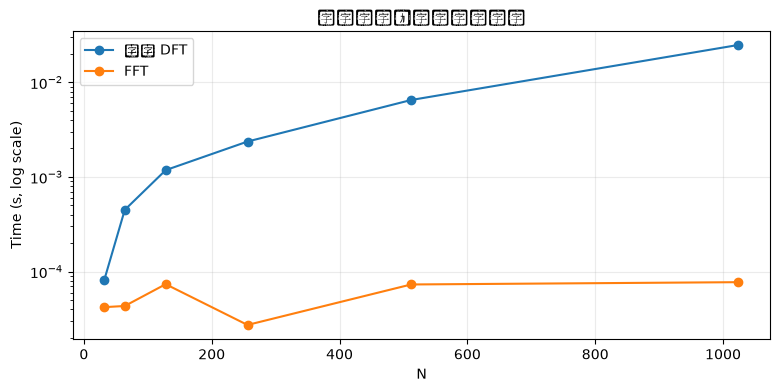

In [8]:
sizes = [32, 64, 128, 256, 512, 1024]
slow_times, fast_times = [], []
rng = np.random.default_rng(0)
for N in sizes:
    data = rng.normal(size=N)
    begin = time.perf_counter(); slow_dft(data); slow_times.append(time.perf_counter()-begin)
    begin = time.perf_counter(); np.fft.fft(data); fast_times.append(time.perf_counter()-begin)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sizes, slow_times, 'o-', label='直接 DFT')
ax.plot(sizes, fast_times, 'o-', label='FFT')
ax.set_yscale('log'); ax.set_xlabel('N'); ax.set_ylabel('Time (s, log scale)')
ax.set_title('相同结果，不同计算速度'); ax.legend(); ax.grid(alpha=0.25)
plt.show()

## 8. 频率 bin 与分辨率

N 点 FFT 在采样率 $f_s$ 下，bin 间隔为：

$$\Delta f=f_s/N$$

例如 16 kHz、512 点 FFT：$16000/512=31.25$ Hz。第 k 个 bin 对应 $k\times31.25$ Hz。对于实数音频，通常只保留 0 到 $f_s/2$，因此 512 点 FFT 有 257 个非负频率 bin。

In [9]:
def bin_calculator(sample_rate=16000, n_fft=512, bin_index=10):
    spacing = sample_rate/n_fft
    print(f'bin 间隔: {spacing:.3f} Hz')
    print(f'第 {bin_index} 个 bin: {bin_index*spacing:.3f} Hz')
    print(f'非负频率 bin 数: {n_fft//2+1}')

widgets.interact(
    bin_calculator,
    sample_rate=widgets.Dropdown(options=[8000,16000,44100,48000],value=16000,description='采样率'),
    n_fft=widgets.Dropdown(options=[128,256,512,1024,2048],value=512,description='n_fft'),
    bin_index=widgets.IntSlider(value=10,min=0,max=64,step=1,description='bin')
)

interactive(children=(Dropdown(description='采样率', index=1, options=(8000, 16000, 44100, 48000), value=16000), …

<function __main__.bin_calculator(sample_rate=16000, n_fft=512, bin_index=10)>

### 练习 3

1. 8 kHz、256 点 FFT 的 bin 间隔是多少？
2. 16 kHz、512 点 FFT 的第 20 个 bin 是多少 Hz？
3. 1024 点实数 FFT 有多少个非负频率 bin？

答案：31.25 Hz；625 Hz；513 个。

## 9. Zero padding：点更多，不等于信息更多

一帧只有 400 个采样点，却可以做 512 点 FFT：末尾补 112 个 0。这样频谱曲线采样更密，更容易定位峰，但真实分辨能力仍主要由原始观察时长决定。

<USER_HOME>\AppData\Local\Temp\ipykernel_15392\3452013467.py:12: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\3452013467.py:12: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\3452013467.py:12: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\3452013467.py:12: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\3452013467.py:12: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\3452013467.py:

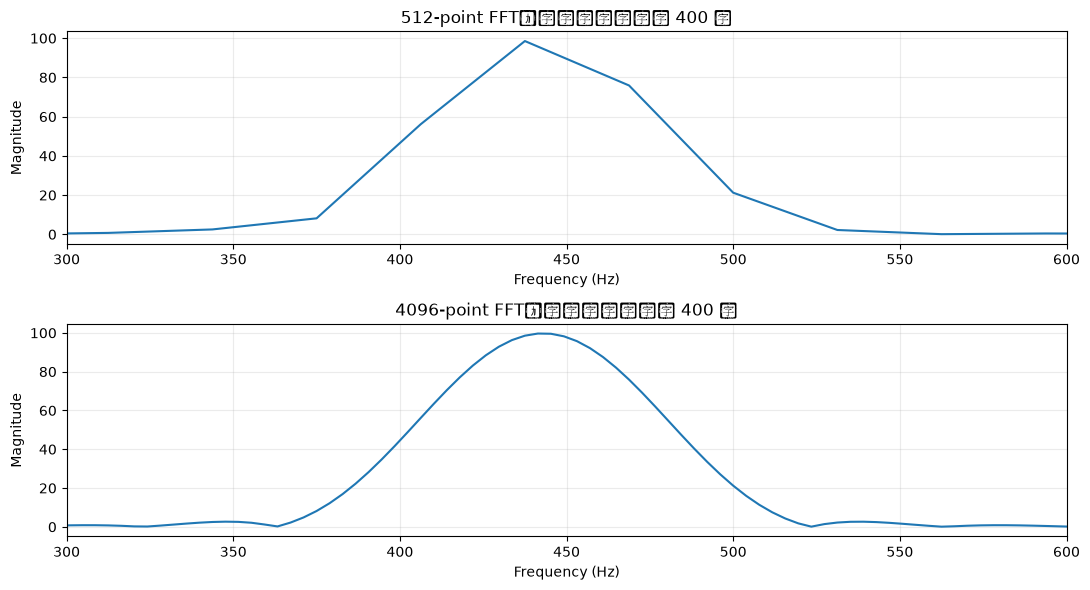

In [10]:
sr_z = 16000
N = 400
tt = np.arange(N)/sr_z
tone = np.sin(2*np.pi*443*tt)*np.hanning(N)
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
for ax, nfft in zip(axes, [512, 4096]):
    ff = np.fft.rfftfreq(nfft, 1/sr_z)
    mm = np.abs(np.fft.rfft(tone, n=nfft))
    ax.plot(ff, mm); ax.set_xlim(300, 600)
    ax.set_title(f'{nfft}-point FFT，原始信号仍只有 400 点')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

看图时注意：4096 点 FFT 的曲线更平滑，但没有凭空让 25 ms 信号拥有 10 倍的真实频率分辨能力。它类似把低分辨率曲线插值画得更细。

## 10. 真实语音的一帧频谱

最后读取真实语音，取 25 ms 一帧，乘 Hann 窗后做 FFT。真实语音会出现许多峰，而不是只有一个峰。

<USER_HOME>\AppData\Local\Temp\ipykernel_15392\1445594166.py:16: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\1445594166.py:16: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\1445594166.py:16: UserWarning: Glyph 35821 (\N{CJK UNIFIED IDEOGRAPH-8BED}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\1445594166.py:16: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\1445594166.py:16: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_15392\144

<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36825 (\N{CJK UNIFIED IDEOGRAPH-8FD9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


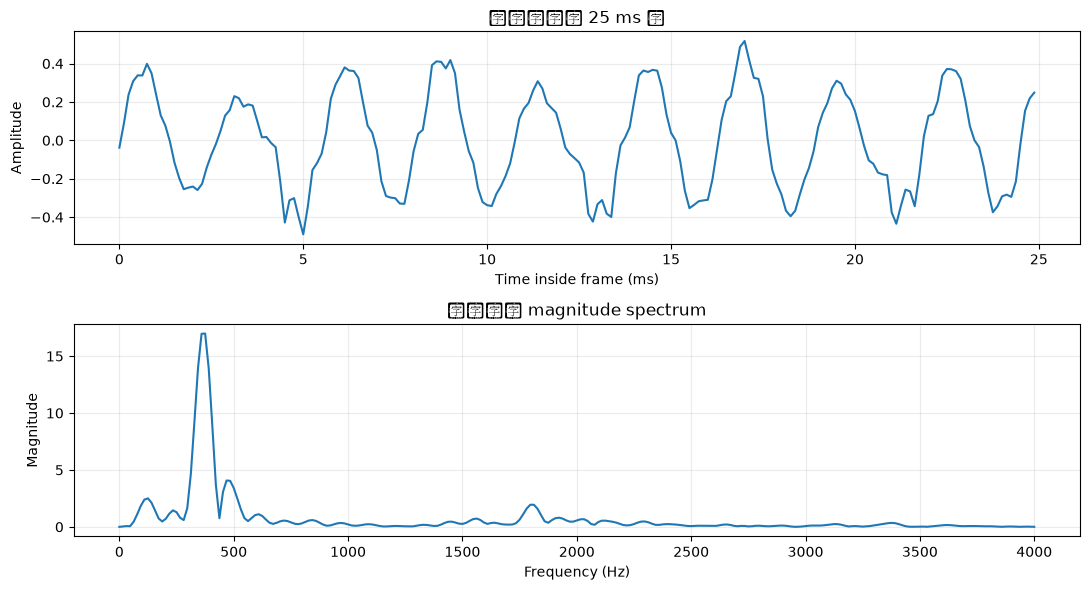

In [11]:
audio, audio_sr = sf.read(ROOT/'data'/'0_jackson_0.wav')
if audio.ndim > 1: audio = audio.mean(axis=1)
frame_n = round(0.025*audio_sr)
start = round(0.20*audio_sr)
frame = audio[start:start+frame_n]
windowed = frame*np.hanning(frame_n)
n_fft = 512
spec = np.abs(np.fft.rfft(windowed, n=n_fft))
ff = np.fft.rfftfreq(n_fft, 1/audio_sr)
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(np.arange(frame_n)/audio_sr*1000, frame)
axes[0].set(title='真实语音的 25 ms 帧', xlabel='Time inside frame (ms)', ylabel='Amplitude')
axes[1].plot(ff, spec)
axes[1].set(title='这一帧的 magnitude spectrum', xlabel='Frequency (Hz)', ylabel='Magnitude')
for ax in axes: ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 本课测试

1. 波形图和频谱图的横轴分别是什么？
2. 两个正弦波相加后，频谱通常出现几个主要峰？
3. 峰的位置和峰的高度分别表示什么？
4. DFT 可以直观理解为什么过程？
5. FFT 与 DFT 的数学结果是否相同？
6. 为什么实际程序通常使用 FFT？
7. 16 kHz、512 点 FFT 的 bin 间隔是多少？
8. 为什么实数信号的 512 点 FFT 通常保留 257 个 bin？
9. 把 400 点信号补零到 4096 点，真实信息会增加吗？
10. 为什么真实人声的频谱比纯音复杂？

参考答案：1 时间/频率；2 两个；3 频率/相对强度；4 用不同频率逐个匹配；5 相同；6 更快；7 31.25 Hz；8 负频率与正频率对称，保留 0～Nyquist；9 不会，只让频谱采样更密；10 人声包含基频、谐波、声道共振和噪声等成分。

## 小结

- 波形回答：振幅怎样随时间变化？
- 频谱回答：信号里有哪些频率，各有多强？
- DFT 是从时域到频域的数学变换。
- FFT 是更快计算 DFT 的算法，不是另一种频谱。
- bin 间隔为 $f_s/N$。
- zero padding 让频谱画得更密，但不创造新的声音信息。

下一课：STFT。我们会把每一帧的频谱按时间排列起来，得到真正的声谱图。

<!-- course-upgrade-v2 -->
## 强化练习：第 3 课专属题库

请先把答案写进新的 Markdown/Code cell，再展开自评标准。

### A. 基础回忆

1. 不看上文，分别定义 `DFT`、`FFT`、`频率 bin`。
2. 哪一个量/状态是本课最容易在模块边界丢失的？它的单位和 shape 是什么？
3. 本课至少写出两个“看起来能运行，但结果其实错误”的例子。

### B. 预测与推理

4. 场景：**观察长度不是整周期的正弦波 FFT**。先预测现象，再说明原因，最后给出一项可以验证猜测的指标。
5. 改变本课最关键参数的 0.5×、1×、2×，分别预测准确率、延迟、内存或数值误差怎样变化。
6. 画一张最小数据流图，在每条边标出 dtype、shape、时间单位或概率/代价方向。

### C. 编程与排错

7. 编程任务：**用显式 DFT 与 np.fft.rfft 对照误差**。至少加入正常、边界、错误输入三类测试。
8. 故意制造一个 off-by-one、shape、状态未 reset 或数值稳定性错误；记录错误现象和定位过程。
9. 不看本课实现，从空白 cell 重写最核心函数，并用原实现作数值对照。

### D. 迁移与表达

10. 跨课任务：**说明 FFT 为什么没有改变 DFT 的数学结果**。
11. 用 90 秒向没有学过 ASR 的人解释本课；禁止只念术语，必须举一个数字或生活例子。
12. 写出一个生产系统中会监控的指标，以及它异常时优先检查的三处位置。

<details><summary>展开自评标准</summary>

- 每题 0～2 分：0=无法回答；1=方向正确但缺少单位、边界或验证；2=解释完整且能用代码/数字验证。
- 24 分满分：达到 19 分再进入下一课；15～18 分次日重做错题；低于 15 分回看本课图和核心代码。
- 第 4 题必须包含“预测—原因—指标”，第 7～9 题必须真正运行测试，第 10 题必须明确上下游 contract。
- 核心答案至少应正确使用：DFT、FFT、频率 bin。

</details>


<!-- course-upgrade-v2 -->
## 间隔复习与离场票

### 离场票（现在完成）

- [ ] 我能不用笔记解释 DFT、FFT、频率 bin。
- [ ] 我能说出本课最常见的错误及其观测现象。
- [ ] 我能从空白重写一个核心函数，并通过至少 3 个测试。
- [ ] 我能说明本课对上一层和下一层接口的影响。

### 复习时间表

- **明天（5 分钟）**：闭卷写出三个核心概念和一个公式/shape。
- **7 天后（15 分钟）**：重做第 4、7、10 题，不运行原答案。
- **30 天后（20 分钟）**：从真实音频或随机张量重新构造一个最小实验。

把错题记录到根目录 `LEARNING_LOG.md`。不要只写“不会”，要写：原判断、证据、正确规则、下次检查动作。
